In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("covid19_sg.csv")
df

,Date,Daily Confirmed,False Positives Found,Cumulative Confirmed,Daily Discharged,Passed but not due to COVID,Cumulative Discharged,Discharged to Isolation,Still Hospitalised,Daily Deaths,...,Cumulative Individuals Vaccinated,Cumulative Individuals Vaccination Completed,Perc population completed at least one dose,Perc population completed vaccination,Sinovac vaccine doses,Cumulative individuals using Sinovac vaccine,Doses of other vaccines recognised by WHO,Cumulative individuals using other vaccines recognised by WHO,Number taken booster shots,Perc population taken booster shots
0,2020-01-23,1,NaN,1,0,0,0,0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-24,2,NaN,3,0,0,0,0,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-25,1,NaN,4,0,0,0,0,4,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-26,0,NaN,4,0,0,0,0,4,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-27,1,NaN,5,0,0,0,0,5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,2022-01-04,842,0.0,281596,271,0,276936,3669,151,3,...,NaN,NaN,88%,87%,NaN,NaN,NaN,NaN,NaN,42%
713,2022-01-05,805,0.0,282401,453,0,277389,4015,155,2,...,NaN,NaN,88%,87%,NaN,NaN,NaN,NaN,NaN,43%
714,2022-01-06,813,0.0,283214,392,0,277781,4449,141,1,...,NaN,NaN,88%,87%,NaN,NaN,NaN,NaN,NaN,44%
715,2022-01-07,777,0.0,283991,338,0,278119,4892,135,2,...,NaN,NaN,89%,87%,NaN,NaN,NaN,NaN,NaN,44%


In [18]:
df.columns

Index(['Date', 'Daily Confirmed', 'False Positives Found',
       'Cumulative Confirmed', 'Daily Discharged',
       'Passed but not due to COVID', 'Cumulative Discharged',
       'Discharged to Isolation', 'Still Hospitalised', 'Daily Deaths',
       'Cumulative Deaths', 'Tested positive demise', 'Daily Imported',
       'Daily Local transmission', 'Local cases residing in dorms MOH report',
       'Local cases not residing in doms MOH report',
       'Intensive Care Unit (ICU)', 'General Wards MOH report',
       'In Isolation MOH report', 'Total Completed Isolation MOH report',
       'Total Hospital Discharged MOH report',
       'Requires Oxygen Supplementation or Unstable', 'Linked community cases',
       'Unlinked community cases', 'Phase', 'Cumulative Vaccine Doses',
       'Cumulative Individuals Vaccinated',
       'Cumulative Individuals Vaccination Completed',
       'Perc population completed at least one dose',
       'Perc population completed vaccination', 'Sinovac vac

In [19]:
covid = df[['Date','Daily Confirmed','Daily Imported','Daily Local transmission','Intensive Care Unit (ICU)','General Wards MOH report','Phase']]
covid

,Date,Daily Confirmed,Daily Imported,Daily Local transmission,Intensive Care Unit (ICU),General Wards MOH report,Phase
0,2020-01-23,1,1,0,0,NaN,NaN
1,2020-01-24,2,2,0,0,NaN,NaN
2,2020-01-25,1,1,0,0,NaN,NaN
3,2020-01-26,0,0,0,0,NaN,NaN
4,2020-01-27,1,1,0,0,NaN,NaN
...,...,...,...,...,...,...,...
712,2022-01-04,842,502,340,13,168.0,Transition Phase
713,2022-01-05,805,439,366,14,171.0,Transition Phase
714,2022-01-06,813,390,423,13,158.0,Transition Phase
715,2022-01-07,777,396,381,12,153.0,Transition Phase


In [20]:
covid.info()

covid.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 717 entries, 0 to 716
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       717 non-null    object 
 1   Daily Confirmed            717 non-null    int64  
 2   Daily Imported             717 non-null    int64  
 3   Daily Local transmission   717 non-null    int64  
 4   Intensive Care Unit (ICU)  717 non-null    int64  
 5   General Wards MOH report   660 non-null    float64
 6   Phase                      642 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 39.3+ KB


Date                          0
Daily Confirmed               0
Daily Imported                0
Daily Local transmission      0
Intensive Care Unit (ICU)     0
General Wards MOH report     57
Phase                        75
dtype: int64

In [21]:
covid['Date'] = pd.to_datetime(covid["Date"], format='%Y-%m-%d')

C:\Users\user\AppData\Local\Temp\ipykernel_13820\3833752405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid['Date'] = pd.to_datetime(covid["Date"], format='%Y-%m-%d')


In [22]:
covid['General Wards MOH report'] = covid['General Wards MOH report'].fillna(0).astype(int)

C:\Users\user\AppData\Local\Temp\ipykernel_13820\3917302176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid['General Wards MOH report'] = covid['General Wards MOH report'].fillna(0).astype(int)


In [23]:
covid.isnull().sum()

Date                          0
Daily Confirmed               0
Daily Imported                0
Daily Local transmission      0
Intensive Care Unit (ICU)     0
General Wards MOH report      0
Phase                        75
dtype: int64

In [24]:
covid['year_mth'] = covid['Date'].dt.strftime('%m-%Y')
covid

C:\Users\user\AppData\Local\Temp\ipykernel_13820\1494992935.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  covid['year_mth'] = covid['Date'].dt.strftime('%m-%Y')


,Date,Daily Confirmed,Daily Imported,Daily Local transmission,Intensive Care Unit (ICU),General Wards MOH report,Phase,year_mth
0,2020-01-23,1,1,0,0,0,NaN,01-2020
1,2020-01-24,2,2,0,0,0,NaN,01-2020
2,2020-01-25,1,1,0,0,0,NaN,01-2020
3,2020-01-26,0,0,0,0,0,NaN,01-2020
4,2020-01-27,1,1,0,0,0,NaN,01-2020
...,...,...,...,...,...,...,...,...
712,2022-01-04,842,502,340,13,168,Transition Phase,01-2022
713,2022-01-05,805,439,366,14,171,Transition Phase,01-2022
714,2022-01-06,813,390,423,13,158,Transition Phase,01-2022
715,2022-01-07,777,396,381,12,153,Transition Phase,01-2022


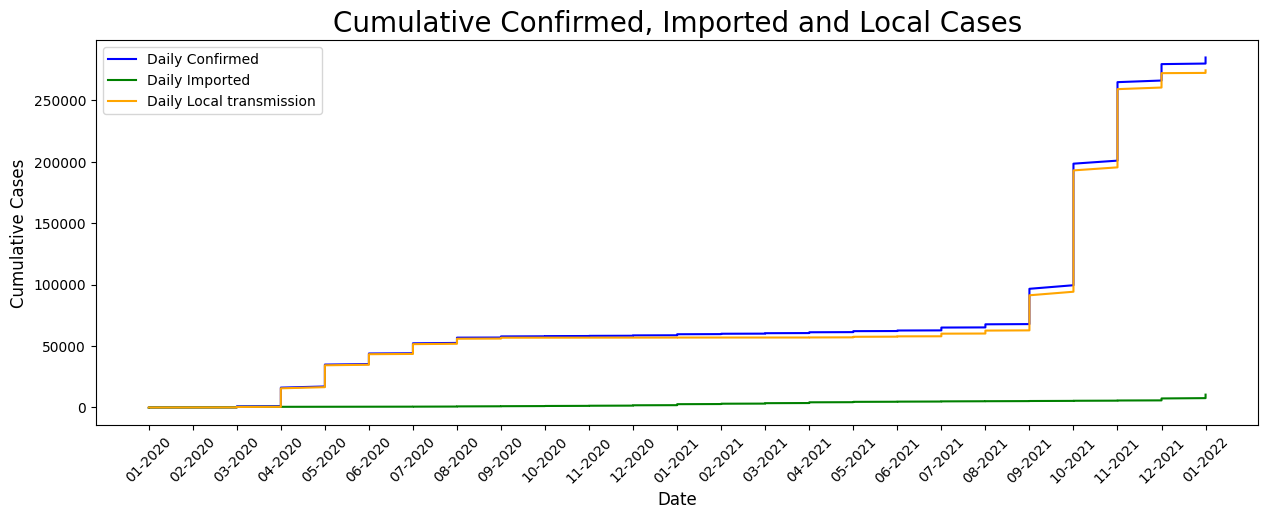

In [25]:
plt.figure(figsize=(15,5))
plt.plot(covid['year_mth'], covid['Daily Confirmed'].cumsum(), color='blue', label = 'Daily Confirmed')
plt.plot(covid['year_mth'], covid['Daily Imported'].cumsum(), color='green', label = 'Daily Imported')
plt.plot(covid['year_mth'], covid['Daily Local transmission'].cumsum(), color='orange', label = 'Daily Local transmission')
plt.title('Cumulative Confirmed, Imported and Local Cases', size=20)
plt.xlabel('Date', size=12)
plt.ylabel('Cumulative Cases', size=12)
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [26]:
covid_phase = covid.dropna(subset=['Phase'])
covid_phase

,Date,Daily Confirmed,Daily Imported,Daily Local transmission,Intensive Care Unit (ICU),General Wards MOH report,Phase,year_mth
75,2020-04-07,106,3,103,29,598,Circuit Breaker,04-2020
76,2020-04-08,142,2,140,29,640,Circuit Breaker,04-2020
77,2020-04-09,287,3,284,29,856,Circuit Breaker,04-2020
78,2020-04-10,198,0,198,32,845,Circuit Breaker,04-2020
79,2020-04-11,191,0,191,31,914,Circuit Breaker,04-2020
...,...,...,...,...,...,...,...,...
712,2022-01-04,842,502,340,13,168,Transition Phase,01-2022
713,2022-01-05,805,439,366,14,171,Transition Phase,01-2022
714,2022-01-06,813,390,423,13,158,Transition Phase,01-2022
715,2022-01-07,777,396,381,12,153,Transition Phase,01-2022


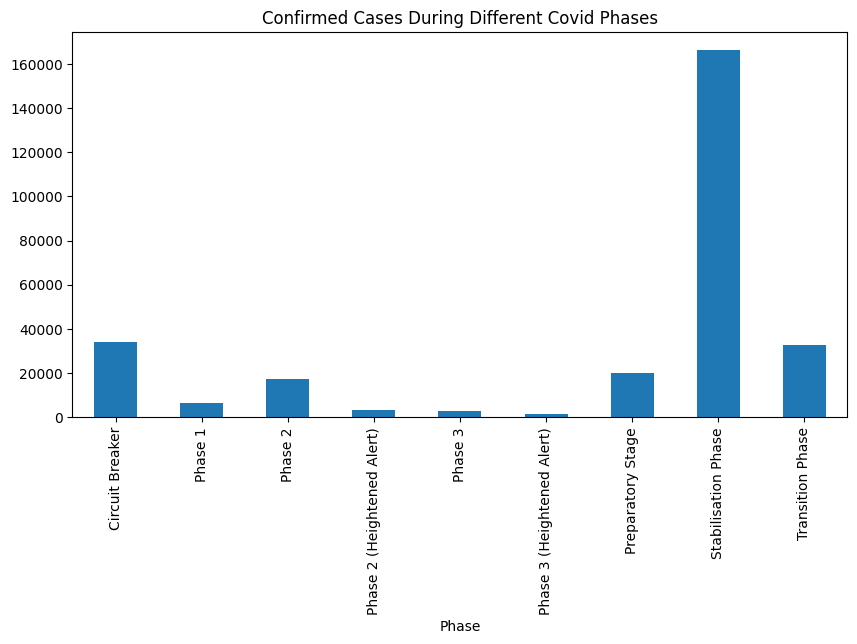

In [27]:
covid_phase_groupby = covid_phase.groupby(['Phase'])[['Daily Confirmed']].agg(['sum'])
covid_phase_groupby.plot(kind='bar', figsize=(10,5), title='Confirmed Cases During Different Covid Phases', legend=False)
print()

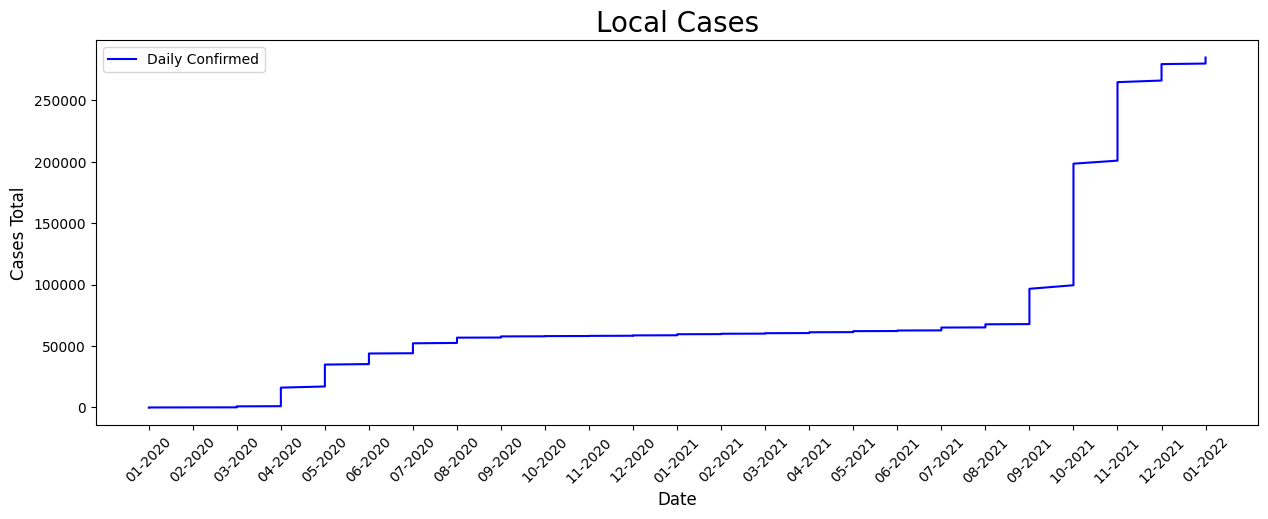

In [31]:
plt.figure(figsize=(15,5))
plt.plot(covid['year_mth'], covid['Daily Confirmed'].cumsum(), color='blue', label = 'Daily Confirmed')
plt.title('Local Cases', size=20)
plt.xlabel('Date', size=12)
plt.ylabel('Cases Total', size=12)
plt.xticks(rotation=45)
plt.legend()
plt.show()